In [2]:
import pandas as pd
data = pd.read_csv('/home/onyxia/work/Stat-App-Montee-des-oceans/my_data_folder/bdd_utilisable/bdd_rename.csv')

data['year_month'] = data['year_month'].str.slice(0, 7)
data['year_month'] = pd.to_datetime(data['year_month'], format='%Y-%m')

data = data.rename(columns={
    'sea level corrected adjusted': 'sea_level',
    'sst_anomaly_filtered': 'sst',
    'greenland_mass_antarctica': 'ice_mass',
    'chlorophylle': 'chlorophyll',
    'salinité': 'salinity'
})

data = data.dropna(subset=['sea_level', 'chlorophyll', 'sst', 'CO2', 'ice_mass', 'salinity'])


In [3]:
X = data[['chlorophyll', 'sst', 'CO2', 'ice_mass', 'salinity']]
y = data['sea_level']

Ridge sans Lasso au préalable -plot sur les données d'entraînement

R² sur données d'entraînement : 0.3869


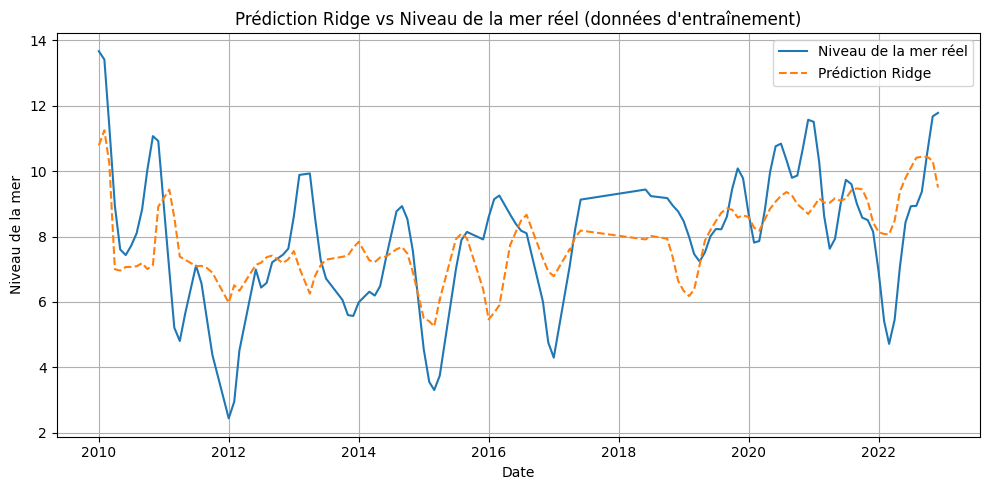

In [7]:
from sklearn.metrics import r2_score
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
import matplotlib.pyplot as plt




degree = 3
alpha = 1.0
pipeline = make_pipeline(
    PolynomialFeatures(degree=degree, include_bias=False),
    StandardScaler(),
    Ridge(alpha=alpha)
)

pipeline.fit(X, y)
y_pred = pipeline.predict(X)


r2 = r2_score(y, y_pred)
print(f"R² sur données d'entraînement : {r2:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(data['year_month'], y, label='Niveau de la mer réel')
plt.plot(data['year_month'], y_pred, label='Prédiction Ridge', linestyle='--')
plt.title('Prédiction Ridge vs Niveau de la mer réel (données d\'entraînement)')
plt.xlabel('Date')
plt.ylabel('Niveau de la mer')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Ridge sans Lasso au préalable - Plot sur les données de test et résidus

R² sur données de test : 0.0693
Erreur quadratique moyenne (MSE) : 4.5240


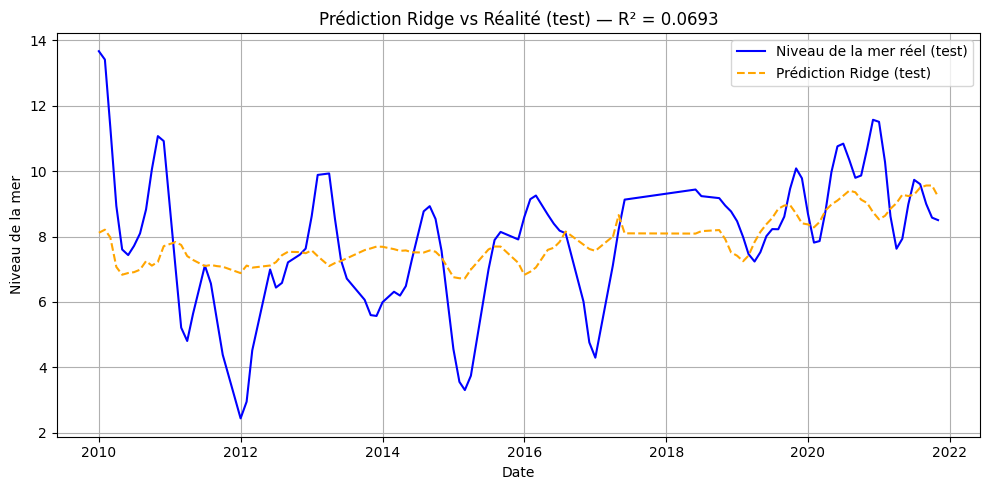

In [8]:
from sklearn.metrics import r2_score, mean_squared_error

dates = data["year_month"]

X_train, X_test, y_train, y_test, dates_train, dates_test = train_test_split(
    X, y, dates, test_size=0.1, shuffle=False)

degree = 3
alpha = 100
pipeline = make_pipeline(
    PolynomialFeatures(degree=degree, include_bias=False),
    StandardScaler(),
    Ridge(alpha=alpha)
)

pipeline.fit(X_train, y_train)

y_pred_test = pipeline.predict(X_test)
y_pred_train=pipeline.predict(X_train)

residuals = y_test - y_pred_test

mse = mean_squared_error(y_test, y_pred_test)

r2_test = r2_score(y_test, y_pred_test)
print(f"R² sur données de test : {r2_test:.4f}")
print(f"Erreur quadratique moyenne (MSE) : {mse:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(dates_train, y_train, label='Niveau de la mer réel (test)', color='blue')
plt.plot(dates_train, y_pred_train , label='Prédiction Ridge (test)', linestyle='--', color='orange')
plt.title(f'Prédiction Ridge vs Réalité (test) — R² = {r2_test:.4f}')
plt.xlabel('Date')
plt.ylabel('Niveau de la mer')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()





In [10]:
feature_names = poly.get_feature_names_out(input_features=X.columns)
selected_features = feature_names[selected_indices]
print("Variables sélectionnées :")
print(selected_features)

Variables sélectionnées :
['sst' 'ice_mass' 'salinity' 'chlorophyll^2' 'chlorophyll sst'
 'chlorophyll ice_mass' 'sst ice_mass' 'sst salinity' 'ice_mass salinity']


In [11]:
X_train_sel = X_train_poly_scaled[:, selected_indices]
X_test_sel = X_test_poly_scaled[:, selected_indices]

ridge = RidgeCV(cv=5)
ridge.fit(X_train_sel, y_train)

# Prédictions
y_train_pred = ridge.predict(X_train_sel)
y_test_pred = ridge.predict(X_test_sel)

# Étape 6 : visualisation avec les bons index temporels
plt.figure(figsize=(14, 5))

# Train
plt.subplot(1, 2, 1)
plt.plot(y_train.index, y_train, label="Observé (train)", color="black")
plt.plot(y_train.index, y_train_pred, label="Prédit (train)", color="blue")
plt.title("Ridge sur données d'entraînement")
plt.legend()

# Test
plt.subplot(1, 2, 2)
plt.plot(y_test.index, y_test, label="Observé (test)", color="black")
plt.plot(y_test.index, y_test_pred, label="Prédit (test)", color="red")
plt.title("Ridge sur données de test")
plt.legend()

plt.tight_layout()
plt.show()

NameError: name 'X_train_poly_scaled' is not defined

Meilleur alpha trouvé via GridSearchCV : 10.0
R² sur données de test : 0.0362
Erreur quadratique moyenne (MSE) sur données de test : 4.6851


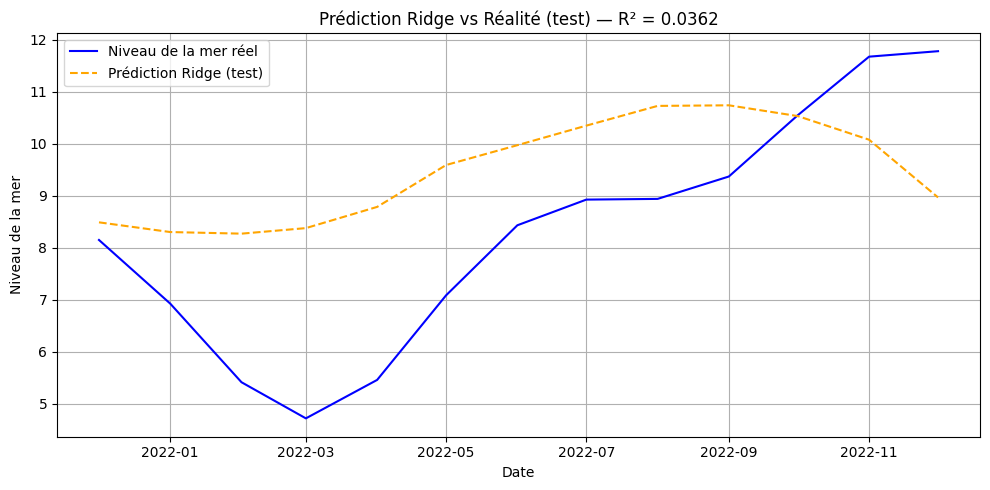

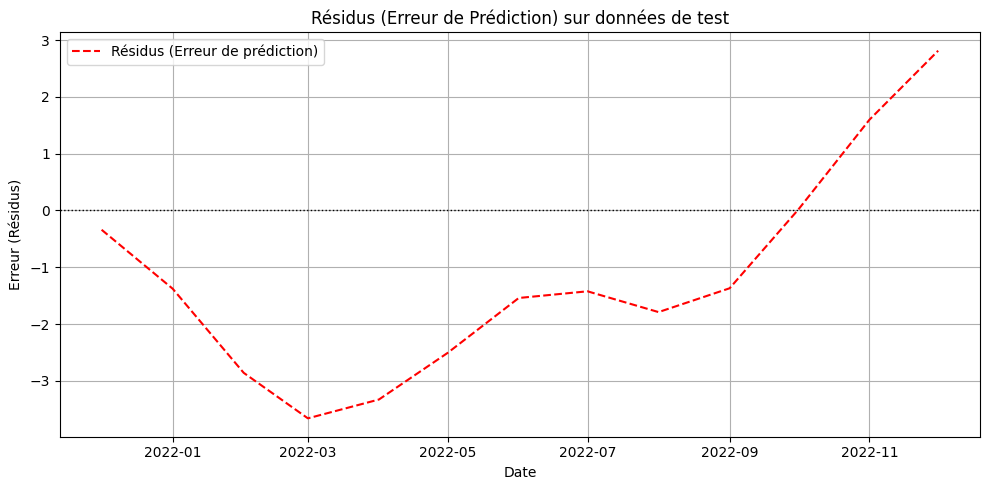

In [13]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

# Séparation des données entre entraînement et test
X_train, X_test, y_train, y_test, dates_train, dates_test = train_test_split(
    X, y, dates, test_size=0.1, shuffle=False)

# Définition du degré du polynôme
degree = 2

# Création du pipeline avec PolynomialFeatures et StandardScaler
pipeline = make_pipeline(
    PolynomialFeatures(degree=degree, include_bias=False),
    StandardScaler(),
    Ridge()
)

# Définir les valeurs à tester pour alpha dans la recherche en grille
param_grid = {'ridge__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}

# Recherche d'alpha optimal avec GridSearchCV et validation croisée
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

# Affichage des meilleurs paramètres alpha trouvés
best_alpha = grid_search.best_params_['ridge__alpha']
print(f"Meilleur alpha trouvé via GridSearchCV : {best_alpha}")

# Entraînement avec le meilleur alpha trouvé
pipeline.set_params(ridge__alpha=best_alpha)
pipeline.fit(X_train, y_train)

# Prédictions sur le jeu de test
y_pred_test = pipeline.predict(X_test)

# Évaluation sur le jeu de test
r2_test = r2_score(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)

print(f"R² sur données de test : {r2_test:.4f}")
print(f"Erreur quadratique moyenne (MSE) sur données de test : {mse:.4f}")

# Visualisation des prédictions vs Réalité
plt.figure(figsize=(10, 5))
plt.plot(dates_test, y_test, label='Niveau de la mer réel', color='blue')
plt.plot(dates_test, y_pred_test , label='Prédiction Ridge (test)', linestyle='--', color='orange')
plt.title(f'Prédiction Ridge vs Réalité (test) — R² = {r2_test:.4f}')
plt.xlabel('Date')
plt.ylabel('Niveau de la mer')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Visualisation des résidus
residuals = y_test - y_pred_test
plt.figure(figsize=(10, 5))
plt.plot(dates_test, residuals, label='Résidus (Erreur de prédiction)', linestyle='--', color='red')
plt.axhline(0, color='black', linewidth=1, linestyle=':')
plt.title('Résidus (Erreur de Prédiction) sur données de test')
plt.xlabel('Date')
plt.ylabel('Erreur (Résidus)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
